# Input:

## import

In [61]:
from sklearn.exceptions import DataConversionWarning
import warnings

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DataConversionWarning)

In [62]:
import torch
import torch.nn as nn
from torch.distributions import Categorical
import numpy as np
import gym

## Data Installation:

In [63]:
import pandas as pd
import numpy as np

data = pd.read_csv("/Users/sonlamtong/Desktop/Python/Thesis/Technical Analysis /Data Set/aapl_Training_Data.csv")
data = data.set_index("Date")

training_data = data.loc[:, ~data.columns.isin(["target", "strength target", "regression target"])].copy()
target= data.loc[:, ["target"]].copy()

data.head()
display(training_data.shape, target.shape)

(2229, 93)

(2229, 1)

['volatility_bbhi', 'volatility_bbli', 'volatility_kchi', 'volatility_kcli', 'trend_psar_up_indicator', 'trend_psar_down_indicator']


Text(0, 0.5, 'Price')

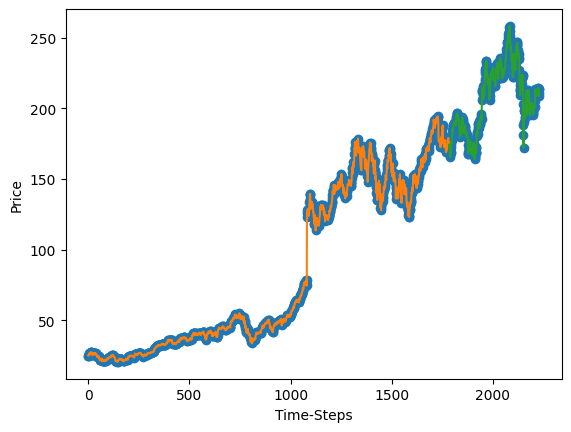

In [64]:
def data_split(split_percentage, df):

    assert 0 < split_percentage < 1, "split_percentage must be a float between 0 and 1 (exclusive)"
    
    split_index = int(len(df) * split_percentage)

    train_df = df.iloc[:split_index].copy()
    test_df = df.iloc[split_index:].copy()
    
    return train_df, test_df

def define_rule_based_indicators_list(X):
    rule_based_indicators =[]
    for col in X.columns:
        if len(X[col].unique()) <= 2:
            rule_based_indicators.append(col)
    
    return rule_based_indicators

print(define_rule_based_indicators_list(training_data))

#X, Valid_set, y, Valid_result = data_split(split_percentage=0.8, df=training_data.reset_index(drop=True))
X, Valid_set = data_split(split_percentage=0.8, df=training_data.reset_index(drop=True))
y, Valid_result = target.reset_index(drop=True).loc[X.index], target.reset_index(drop=True).loc[Valid_set.index]
from matplotlib import pyplot as plt

df = training_data.reset_index(drop=True)
price = df.loc[:, 'close']
plt.plot(price.index, price.values, 'o')

for df in [X, Valid_set]:
    price = df.loc[:, 'close']
    plt.plot(price.index, price.values)
    
plt.xlabel("Time-Steps")
plt.ylabel("Price")

# M1 layers processing:

## Fold CV fucntion:

In [65]:
def purged_kfold_split(X, n_splits=5, lookahead=5, embargo=0):
    fold_size = len(X) // n_splits
    for i in range(n_splits):
        test_start = i * fold_size
        test_end = (i + 1) * fold_size

        # Embargo
        embargo_start = test_end + 1
        embargo_end = embargo_start + embargo

        # Purge overlaps
        train_idx = list(range(0, test_start - lookahead)) + list(range(embargo_end, len(X)))
        test_idx = list(range(test_start, test_end))

        yield train_idx, test_idx

## Adding models:

In [66]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
import joblib

model_paths = ["knn_model_with_threshold.pkl", "logr_model_with_threshold.pkl", "rf_model_with_threshold.pkl", "xgb_model_with_threshold.pkl"]
model_names = ["KNNs", "LogR", "RF", "XGB"]
model_infor = {}

for name, path in zip(model_names, model_paths):
    model_infor[name] = joblib.load(f"/Users/sonlamtong/Desktop/Python/Thesis/Technical Analysis /ML models/prediction dataset/Classification/{path}")

In [67]:
for key, infor in model_infor.items():
    print(f"{key}: {infor['model']}")

KNNs: KNeighborsClassifier(algorithm='brute', leaf_size=71, n_jobs=-1, n_neighbors=29,
                     p=1)
LogR: LogisticRegression(C=0.26701973434500526, l1_ratio=0.4617895914797829,
                   max_iter=1000, penalty='elasticnet', random_state=42,
                   solver='saga')
RF: RandomForestClassifier(class_weight='balanced', max_depth=19,
                       max_features=0.17056866714444247, min_samples_split=3,
                       n_estimators=107, n_jobs=-1, random_state=42)
XGB: XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.0537927537850279, device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric='logloss', feature_types=None, feature_weights=None,
              gamma=9.492813163232885, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.3949954489143

## M1-models Processing:

In [68]:
from sklearn.metrics import f1_score, accuracy_score

sub_training_data = X.copy()
sub_testing_data = Valid_set.copy()

for name, infor in model_infor.items():
    model = infor["model"]
    
    # record in the train-set
    X_train_1 = X.loc[:, infor["feature set"]].copy()
    model.fit(X_train_1, y)
    
    y_proba = model.predict_proba(X_train_1)[:, 1]
    '''
    y_pred = model.predict(X_train_1)
    '''
    y_pred = (y_proba > infor["threshold"]).astype(int)
    if len(np.unique(y_pred)) < 2:
        continue
    
    sub_training_data[f"{name}_proba"] = y_proba
    sub_training_data[f"{name}_prediction"] = y_pred
    #sub_training_data[f"{name}_valid"] = ( y_pred == y.to_numpy().T[0] ).astype(int)
    
    print()
    print( f"{name}_f1_score: {f1_score(y_true=y, y_pred=y_pred)}" )
    print( f"{name}_accuracny_score: {accuracy_score(y_true=y, y_pred=y_pred)}" )
    print(np.unique(y_pred, return_counts=True))
    
    # record in the test-set
    X_test_1 = Valid_set.loc[:, infor["feature set"]].copy()
    
    y_proba = model.predict_proba(X_test_1)[:, 1]
    
    '''
    y_pred = model.predict(X_test_1)
    '''
    y_pred = (y_proba > infor["threshold"]).astype(int)

    sub_testing_data[f"{name}_proba"] = y_proba
    sub_testing_data[f"{name}_prediction"] = y_pred
    
    print( f"{name}_f1_score: {f1_score(y_true=Valid_result, y_pred=y_pred)}" )
    print(np.unique(y_pred, return_counts=True))


KNNs_f1_score: 0.6923359002566923
KNNs_accuracny_score: 0.5294447560291643
(array([0, 1]), array([   1, 1782]))
KNNs_f1_score: 0.7034883720930233
(array([0, 1]), array([  2, 444]))

LogR_f1_score: 0.6930181012190617
LogR_accuracny_score: 0.5339315759955132
(array([0, 1]), array([  21, 1762]))
LogR_f1_score: 0.6881720430107527
(array([0, 1]), array([ 39, 407]))

RF_f1_score: 0.9994711792702274
RF_accuracny_score: 0.9994391475042064
(array([0, 1]), array([837, 946]))
RF_f1_score: 0.6876876876876877
(array([0, 1]), array([ 24, 422]))


In [69]:
display(sub_training_data.head())
display(sub_testing_data.head())

,close,high,low,open,volume,return,log_return,volume_adi,volume_obv,volume_cmf,...,momentum_kama,others_dr,others_dlr,others_cr,KNNs_proba,KNNs_prediction,LogR_proba,LogR_prediction,RF_proba,RF_prediction
0,25.166327,25.220321,24.858103,24.957095,150694000,0.371222,0.014861,6.073737e+08,13241600.0,0.215077,...,25.103578,-2.138998,-2.162206,-6.527499,0.448276,1,0.518232,1,0.205095,0
1,24.981848,25.197829,24.867107,25.148333,156930400,-0.184479,-0.007357,7.131407e+08,163935600.0,0.188377,...,25.093006,-0.412580,-0.413434,-5.128069,0.586207,1,0.533313,1,0.760413,1
2,25.137087,25.141586,24.772618,24.927855,119036800,0.155239,0.006195,6.651012e+08,7005200.0,0.180302,...,25.079918,1.551328,1.539418,-5.823516,0.551724,1,0.524087,1,0.802017,1
3,25.596043,25.686035,24.932351,25.049340,195871200,0.458956,0.018093,7.812351e+08,126042000.0,0.215445,...,25.078755,-1.570987,-1.583457,-5.238296,0.655172,1,0.503315,1,0.257434,0
4,25.593792,26.003257,25.580292,25.647787,167180800,-0.002251,-0.000088,9.303309e+08,321913200.0,0.158693,...,25.068155,0.811278,0.808005,-3.508127,0.620690,1,0.520326,1,0.855243,1


,close,high,low,open,volume,return,log_return,volume_adi,volume_obv,volume_cmf,...,momentum_kama,others_dr,others_dlr,others_cr,KNNs_proba,KNNs_prediction,LogR_proba,LogR_prediction,RF_proba,RF_prediction
1783,174.331985,176.057069,173.608250,174.074221,54764400,-1.298767,-0.007422,9.929642e+09,5.284131e+09,0.069149,...,175.697699,-1.999212,-2.019466,562.092207,0.517241,1,0.563285,1,0.375277,0
1784,173.955261,176.314840,173.687573,174.530274,59302900,-0.376724,-0.002163,9.907249e+09,5.229367e+09,0.080910,...,175.672998,-0.888954,-0.892928,557.196119,0.620690,1,0.554271,1,0.480511,1
1785,171.397400,173.915610,171.159453,173.806553,64244000,-2.557861,-0.014813,9.860030e+09,5.170064e+09,0.057929,...,175.680723,0.494455,0.493237,555.775945,0.482759,1,0.543908,1,0.387337,1
1786,171.516357,172.517690,168.472678,169.444285,55980100,0.118958,0.000694,9.806879e+09,5.105820e+09,0.067749,...,175.730883,0.738034,0.735324,546.133328,0.517241,1,0.502145,1,0.497906,1
1787,171.952576,172.180599,169.979637,171.565921,43816600,0.436218,0.002540,9.835144e+09,5.161800e+09,0.152005,...,175.872130,-2.339839,-2.367648,546.581774,0.413793,1,0.434428,1,0.500749,1


## dataframe set-up with the m1 layers:

In [70]:
from sklearn.metrics import f1_score, accuracy_score
from sklearn.model_selection import cross_val_score

def voting_method(data):
    score_array = []
    X_meta = []
    for name, infor in model_infor.items():
        check = 0
        for i in sub_training_data.columns:
            if name in i:
                check += 1
        if check < 1:
            continue
        
        '''
        y_pred= sub_training_data[f"{name}_prediction"]
        score = f1_score(y_pred=y_pred, y_true= y) 
        '''
        
        cv = purged_kfold_split(X.copy())
        score = cross_val_score(estimator=infor["model"], X=X.loc[:, infor["feature set"]].copy(), y=y.copy(), cv=cv, scoring="f1", n_jobs=-1).mean()
                
        score_array.append( score )
        
        X_meta.append(data[f"{name}_prediction"].tolist())
        print(f"{name}: {score_array[-1]}")

    # Weighted predictions (element-wise multiplication)
    score_array = np.array(score_array)
    #normalized_weights = score_array / score_array.sum()
    normalized_weights = score_array

    X_weighted = np.array(X_meta) * normalized_weights.reshape(len(score_array),1)
    
    # Same preds array as above
    weighted_votes = np.dot(X_weighted.T, normalized_weights)  # shape: (n_samples,)
    threshold = normalized_weights.sum() / 2
    final_preds = (weighted_votes >= threshold).astype(int)
    
    return final_preds

signals = []
record_1 = []
record_2 = []

def clustering_signal(target_signal: int, final_preds: np.array, data: pd.DataFrame = None): # just keep signal {1} or {0} for the input of the M2-layer

    zeros_array = np.zeros(len(final_preds))
    indexes = np.where(final_preds == target_signal)

    zeros_array[indexes] = 1
    
    if data is None:
        return zeros_array
    else:
        return data.iloc[indexes]

## M1-models Validation:

In [71]:
train_preds = voting_method(data=sub_training_data.copy())
test_preds = voting_method(data=sub_testing_data.copy())

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/neighbors/_classification.py:238: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/neighbors/_classification.py:238: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/neighbors/_classification.py:238: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/neighb

KNNs: 0.562346141392223


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:1310: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Library/Frameworks/Python.framework/Versions/3.12/l

LogR: 0.6322788457069979


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


...

KNNs: 0.562346141392223


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:349: ConvergenceWarning: The ma

LogR: 0.6322788457069979


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RF: 0.5981790888274523


In [72]:
y_test, y_train = Valid_result.copy(), y.copy()
for i in [train_preds, test_preds, y_test, y_train]:
    i[i == 0] = -1

print(f"Train Count: {np.unique(train_preds, return_counts=True)}")
print(f"Test  Count: {np.unique(test_preds, return_counts=True)}")
print()
print(f"Train F1: {f1_score(y_pred=train_preds, y_true=y_train)}")
print(f"Test F1: {f1_score(y_pred=test_preds, y_true=y_test)}")
print()
train_returns = sub_training_data.iloc[np.where(train_preds == 1)]['return'].sum()
train_total_returns = sub_training_data.iloc[ np.where(sub_training_data['return'] > 0) ]['return'].sum()
test_returns = sub_testing_data.iloc[np.where(test_preds == 1)]['return'].sum()
test_total_returns = sub_testing_data.iloc[ np.where(sub_testing_data['return'] > 0) ]['return'].sum()
print(f"Train Return Rate: {train_returns / train_total_returns}")
print(f"Test Return Rate: {test_returns / test_total_returns}")

Train Count: (array([-1,  1]), array([845, 938]))
Test  Count: (array([-1,  1]), array([ 58, 388]))

Train F1: 0.9952203929899097
Test F1: 0.6708860759493671

Train Return Rate: 0.1108909425662112
Test Return Rate: 0.1272254670674764


In [73]:
final_preds = train_preds.copy()
clustering_signal(target_signal=-1, final_preds=final_preds)

array([1., 0., 0., ..., 1., 1., 1.])

# Data Preprocessing:

## Feature Scaling Functions:

In [74]:
# ---------------------------
# Feature Scaling Functions:
# ---------------------------

from sklearn.preprocessing import MinMaxScaler, StandardScaler
import pandas as pd

def scale_minmax(data):
    """
    Scales features to range [0, 1] using MinMaxScaler.
    Useful for Chi2 and distance-based methods.
    """
    X= data.copy()
    rule_based_indicators = define_rule_based_indicators_list(X.copy())
    if rule_based_indicators != []:
        X = X.loc[:, ~X.columns.isin(rule_based_indicators)]
        
    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(X)

    return pd.concat([pd.DataFrame(X_scaled, columns=X.columns, index=X.index), data.loc[:, rule_based_indicators]], axis='columns')

def scale_standard(data):
    """
    Scales features to zero mean and unit variance using StandardScaler.
    Useful for linear models (L1), permutation, and statistical tests like F-test.
    """
    X= data.copy()
    rule_based_indicators = define_rule_based_indicators_list(X.copy())
    if rule_based_indicators != []:
        X = X.loc[:, ~X.columns.isin(rule_based_indicators)]
        
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    return pd.concat([pd.DataFrame(X_scaled, columns=X.columns, index=X.index), data.loc[:, rule_based_indicators]], axis='columns')

def scale_none(X):
    return X.copy()

## DataSet:

In [75]:
l = X.columns.tolist().copy()
l.remove('return')
df1 = sub_training_data.loc[:, ~sub_training_data.columns.isin(l)]
df2 = sub_testing_data.loc[:, ~sub_testing_data.columns.isin(l)]
'''
df1 = clustering_signal(data=df1, final_preds=train_preds, target_signal=1)
df2 = clustering_signal(data=df2, final_preds=test_preds, target_signal=1)
'''

df1['final_preds'] = voting_method(data=df1.copy())
df2['final_preds'] = voting_method(data=df2.copy())

scale_1 = scale_standard(df1)
scale_2 = scale_standard(df2)

for j in scale_1.columns:
    if j != 'return':
        df1[j] = scale_1[j]
for j in scale_2.columns:
    if j != 'return':
        df2[j] = scale_2[j]

KNNs: 0.562346141392223


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/neighbors/_classification.py:238: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/neighbors/_classification.py:238: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/neighbors/_classification.py:238: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/neighb

LogR: 0.6322788457069979


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RF: 0.5981790888274523
KNNs: 0.562346141392223


/var/folders/j_/0q2qhjf90s7gbt6hw8zb3_jc0000gn/T/ipykernel_57950/2662770933.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['final_preds'] = voting_method(data=df1.copy())
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/neighbors/_classification.py:238: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/neighbors/_classification.py:238: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel

LogR: 0.6322788457069979
RF: 0.5981790888274523


/var/folders/j_/0q2qhjf90s7gbt6hw8zb3_jc0000gn/T/ipykernel_57950/2662770933.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['final_preds'] = voting_method(data=df2.copy())
/var/folders/j_/0q2qhjf90s7gbt6hw8zb3_jc0000gn/T/ipykernel_57950/2662770933.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1[j] = scale_1[j]
/var/folders/j_/0q2qhjf90s7gbt6hw8zb3_jc0000gn/T/ipykernel_57950/2662770933.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try usi

In [76]:
df1.loc[ df1['return'] > 0 , ['return']].sum()

return    1034.782913
dtype: float64

In [77]:
display(df1), display(df2)

,return,KNNs_proba,KNNs_prediction,LogR_proba,LogR_prediction,RF_proba,RF_prediction,final_preds
0,0.371222,-0.991191,1,-0.199782,1,-1.078552,0,0
1,-0.184479,0.681195,1,0.087923,1,0.778184,1,1
2,0.155239,0.263098,1,-0.088090,1,0.917288,1,1
3,0.458956,1.517388,1,-0.484347,1,-0.903552,0,0
4,-0.002251,1.099292,1,-0.159827,1,1.095254,1,1
...,...,...,...,...,...,...,...,...
1778,1.397934,-0.154998,1,1.164224,1,0.921517,1,1
1779,0.902176,0.263098,1,0.948126,1,-1.080119,0,0
1780,-1.844025,-0.573095,1,0.817602,1,-1.217978,0,0
1781,-0.128906,-0.991191,1,0.798079,1,-1.243784,0,0


,return,KNNs_proba,KNNs_prediction,LogR_proba,LogR_prediction,RF_proba,RF_prediction,final_preds
1783,-1.298767,-0.190898,1,0.342209,1,-1.664830,0,0
1784,-0.376724,1.125707,1,0.240898,1,-0.255614,1,1
1785,-2.557861,-0.629766,1,0.124429,1,-1.503334,1,1
1786,0.118958,-0.190898,1,-0.344934,1,-0.022674,1,1
1787,0.436218,-1.507503,1,-1.106004,1,0.015404,1,1
...,...,...,...,...,...,...,...,...
2224,-0.389999,2.003444,1,0.075932,1,-0.415250,1,1
2225,0.120010,-0.190898,1,-0.011294,1,1.325662,1,1
2226,0.169998,-0.190898,1,0.039823,1,1.157470,1,1
2227,-2.779999,-0.190898,1,-0.391517,1,1.590007,1,1


(None, None)

# PPO Set-up:

In [78]:
#device = torch.device("mps" if torch.mps.is_available() else "cpu")
device = torch.device("mps" if torch.cuda.is_available() else "cpu")
print(device)

cpu


## Environment set-up:

In [79]:
import gym
import numpy as np

class TradingEnv(gym.Env):
    def __init__(self, data):
        super(TradingEnv, self).__init__()
        self.data = data
        self.current_step = 0
        self.position = 0
        self.initial_balance = 10000
        self.done = False

        # Define action space: Buy (1), Hold (0)
        self.action_space = gym.spaces.Discrete(2)

        # Observation space based on data columns
        self.observation_space = gym.spaces.Box(
            low=-np.inf,
            high=np.inf,
            shape=(len(data.columns),),
            dtype=np.float32
        )

    def reset(self):
        self.current_step = 0
        self.balance = self.initial_balance
        self.total_profit = 0
        self.position = 0
        self.entry_price = 0
        self.done = False

        return self._get_observation()

    def _get_observation(self):
        obs = self.data.iloc[self.current_step].values
        return obs.astype(np.float32)

    def step(self, action):
        self.current_step += 1
        reward = 0
        rate_of_return = 0

        if self.current_step >= len(self.data) - 2:
            self.done = True

        price_change = self.data['return'].iloc[self.current_step + 1]

        if action == 1:
            reward = price_change
        elif action == 0:
            reward = 0

        obs = self._get_observation()
        actual_movement = int(price_change > 0)
        actual_returns = price_change if price_change > 0 else 0

        return obs, reward, self.done, {
            "actual_movement": actual_movement,
            "Rate of Return": rate_of_return,
            "Actual Return": actual_returns
        }

## Memmory Set-up:

In [80]:
class Memory:
    def __init__(self):
        self.clear()

    def add(self, state, action, logprob, reward, done, value):
        self.states.append(state)
        self.actions.append(action)
        self.logprobs.append(logprob)
        self.rewards.append(reward)
        self.dones.append(done)
        self.values.append(value)

    def get_batch(self):
        return {
            'states': torch.tensor(self.states, dtype=torch.float32).unsqueeze(0),
            'actions': torch.tensor(self.actions),
            'logprobs': torch.tensor(self.logprobs, dtype=torch.float32),
            'rewards': torch.tensor(self.rewards, dtype=torch.float32),
            'dones': torch.tensor(self.dones, dtype=torch.float32),
            'values': torch.tensor(self.values, dtype=torch.float32),
        }

    def clear(self):
        self.states = []
        self.actions = []
        self.logprobs = []
        self.rewards = []
        self.dones = []
        self.values = []


## Agent function:

In [ ]:
import torch.nn as nn
import torch
import torch.nn.functional as F
from torch.distributions import Categorical
'''
class ActorCriticLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, batch_first=True)
        #self.actor = nn.Linear(hidden_dim, output_dim)
        self.actor = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, output_dim),
        )
        #self.critic = nn.Linear(hidden_dim, 1)
        self.critic = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(), 
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, x, hx=None):
        #x = x.unsqueeze(0).unsqueeze(0)  # (1, 1, state_dim)
        x = x.unsqueeze(0)  # (1, 1, state_dim)
        lstm_out, hx = self.lstm(x, hx)  # (1, 1, hidden)
        hidden = lstm_out.squeeze(0).squeeze(0)  # (hidden)
        logits = self.actor(hidden)
        value = self.critic(hidden)
        return logits, value, hx

    def act(self, state, hx=None):
        logits, value, hx = self.forward(state, hx)
        probs = F.softmax(logits, dim=-1)
        dist = Categorical(probs)
        action = dist.sample()
        return action.item(), dist.log_prob(action), value.item(), hx
'''
class ActorCriticLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_lstm_layers=2):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_lstm_layers

        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_lstm_layers,
            batch_first=True,
        )

        self.actor = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim)
        )

        self.critic = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, x, hx=None):
        if len(np.array(x).shape) <= 2:
            x = x.unsqueeze(0)  # (1, state_dim) -> (1, 1, state_dim)
        else:
            x = x.squeeze(0)  # (1, 1, state_dim) -> (1, state_dim)
            
        if hx is None:
            h_0 = torch.zeros(self.num_layers, self.hidden_dim).to(x.device)
            c_0 = torch.zeros(self.num_layers, self.hidden_dim).to(x.device)
            hx = (h_0, c_0)
        
        lstm_out, hx = self.lstm(x, hx)  # (1, 1, hidden_dim)
        hidden = lstm_out.squeeze(0).squeeze(0)  # (hidden_dim)
        
        logits = self.actor(hidden)
        value = self.critic(hidden)
        return logits, value, hx

    def act(self, state, hx=None):
        logits, value, hx = self.forward(state, hx)
        probs = F.softmax(logits, dim=-1)
        dist = Categorical(probs)
        action = dist.sample()
        return action.item(), dist.log_prob(action), value.item(), hx

## Objectve function:

In [ ]:
class PPO_LSTM:
    def __init__(self, state_dim, action_dim, hidden_dim=64, lr=3e-4, gamma=0.99, eps_clip=0.2, K_epochs=4):
        self.model = ActorCriticLSTM(state_dim, hidden_dim, action_dim).to(device)
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=lr)
        self.gamma = gamma
        self.eps_clip = eps_clip
        self.K_epochs = K_epochs

    def compute_advantages(self, rewards, dones, values):
        returns = []
        advantages = []
        gae = 0
        next_value = 0

        for step in reversed(range(len(rewards))):
            mask = 1.0 - dones[step]
            delta = rewards[step] + self.gamma * next_value * mask - values[step]
            gae = delta + self.gamma * 0.95 * gae * mask
            advantages.insert(0, gae)
            next_value = values[step]
            returns.insert(0, gae + values[step])

        advantages = torch.tensor(advantages, dtype=torch.float32).to(device)
        returns = torch.tensor(returns, dtype=torch.float32).to(device)
        advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)
        return returns, advantages

    def update(self, memory):
        states = memory['states'].to(device)          # (batch, seq_len, state_dim)
        actions = memory['actions'].to(device)        # (batch, seq_len)
        old_logprobs = memory['logprobs'].to(device)  # (batch, seq_len)
        rewards = memory['rewards'].to(device)        # (batch, seq_len)
        dones = memory['dones'].to(device)            # (batch, seq_len)
        values = memory['values'].to(device)          # (batch, seq_len)

        returns, advantages = self.compute_advantages(rewards, dones, values)

        for _ in range(self.K_epochs):
            hx = None  # reset hidden state for each epoch

            # Forward pass for entire batch
            logits, state_values, hx = self.model.forward(states, hx)  # logits: (batch, seq_len, action_dim)
            dist = Categorical(logits=logits)
            new_logprobs = dist.log_prob(actions)  # (batch, seq_len)
            entropy = dist.entropy().mean()

            ratios = torch.exp(new_logprobs - old_logprobs)
            surr1 = ratios * advantages
            surr2 = torch.clamp(ratios, 1 - self.eps_clip, 1 + self.eps_clip) * advantages

            policy_loss = -torch.min(surr1, surr2).mean()
            value_loss = F.mse_loss(state_values.squeeze(-1), returns)
            entropy_loss = -entropy

            loss = policy_loss + 0.5 * value_loss + 0.01 * entropy_loss

            self.optimizer.zero_grad()
            loss.backward()
            self.optimizer.step()

        return loss, {
            'policy_loss': policy_loss.item(),
            'value_loss': value_loss.item(),
            'entropy_loss': entropy_loss.item()
        }

# Training:

In [83]:
def train_ppo(env, ppo, memory, max_episodes=1000):
    for episode in range(max_episodes):
        state = env.reset()
        ep_reward = 0
        done = False
        hx = None  # Reset hidden state at episode start

        while not done:
            state_tensor = torch.tensor(state, dtype=torch.float32).to(device)

            # Detach hx to prevent backprop through entire history
            if hx is not None:
                hx = (hx[0].detach(), hx[1].detach())

            action, logprob, value, hx = ppo.model.act(state_tensor, hx)
            next_state, reward, done, _ = env.step(action)

            memory.add(state, action, logprob.item(), reward, done, value)
            ep_reward += reward
            state = next_state

        batch = memory.get_batch()
        
        losses = ppo.update(batch)  # Make sure update re-computes forward pass
        memory.clear()

        if episode % 100 == 0:
            print(f"Episode {episode} Reward: {ep_reward:.2f} Losses: {losses[0]}")


## train result:

In [84]:
state_dim, action_dim = len(df1.columns), 2
train_env = TradingEnv(data= df1.copy())
ppo = PPO_LSTM(state_dim, action_dim)
memory = Memory()

train_ppo(train_env, ppo, memory)
### save the trained model
torch.save(ppo.model.state_dict(), "ppo_trained.pth")

Episode 0 Reward: 26.76 Losses: 6.813333988189697
Episode 100 Reward: 197.48 Losses: 12.718302726745605
Episode 200 Reward: 146.69 Losses: 14.200827598571777
Episode 300 Reward: 133.35 Losses: 14.22489070892334
Episode 400 Reward: 132.91 Losses: 15.01649284362793
Episode 500 Reward: 81.77 Losses: 5.46682071685791


KeyboardInterrupt: 

# Testing:

In [59]:
from sklearn.metrics import f1_score, classification_report

def evaluate_ppo(env, ppo, episodes=100, max_timesteps=12000):
    total_rewards = []
    actual_result = {"actual_movement": [], "actual_return": []}
    predictive_result = {"predictive_movement": [], "predictive_return": []}

    for ep in range(episodes):
        state = env.reset()
        total_reward = 0
        hx = None

        actual_values = {"actual_movement": [], "actual_return": []}
        predictive_values = {"predictive_movement": [], "predictive_return": []}

        for _ in range(max_timesteps):
            state_tensor = torch.tensor(state, dtype=torch.float32).to(device)

            with torch.no_grad():
                if hx is not None:
                    hx = (hx[0].detach(), hx[1].detach())
                action, _, _, hx = ppo.model.act(state_tensor, hx)

            state, reward, done, info = env.step(action)
            total_reward += reward

            actual_values["actual_movement"].append(info["actual_movement"])
            actual_values["actual_return"].append(info["Actual Return"])
            predictive_values["predictive_movement"].append(action)
            predictive_values["predictive_return"].append(reward)

            if done:
                break

        total_rewards.append(total_reward)

        for key in actual_result.keys():
            actual_result[key].append(actual_values[key])
        for key in predictive_result.keys():
            predictive_result[key].append(predictive_values[key])

        if ep % 10 == 0:
            print(f"Eval Episode {ep}\tReward: {total_reward:.2f}")

    avg_reward = sum(total_rewards) / len(total_rewards)
    print(f"\nAverage Evaluation Reward: {avg_reward:.2f}")

    return_array = []
    for i in range(len(actual_result["actual_return"])):
        total_actual_return = np.sum(actual_result["actual_return"][i])
        if total_actual_return != 0:
            return_array.append(total_rewards[i] / total_actual_return)
        else:
            return_array.append(0.0)

    rate_of_return = np.mean(return_array)

    f1_array = []
    for i in range(len(actual_result["actual_movement"])):
        f1_array.append(f1_score(
            y_true=actual_result["actual_movement"][i],
            y_pred=predictive_result["predictive_movement"][i],
            zero_division=0
        ))

    full_y_true = np.concatenate(actual_result["actual_movement"])
    full_y_pred = np.concatenate(predictive_result["predictive_movement"])

    return (
        {
            "Mean Rate of Return": rate_of_return,
            "Mean F1-Score": np.mean(f1_array),
        },
        classification_report(full_y_true, full_y_pred, zero_division=0)
    )

## Trained models:

In [60]:
train_env = TradingEnv(data= df1.copy())
test_env = TradingEnv(data= df2.copy())

print(f"Trained model")
ppo.model.load_state_dict(torch.load("ppo_trained.pth"))

# train_set
print("\n" + "TrainSet")
trained_result_train = evaluate_ppo(train_env, ppo)
print(trained_result_train[0])
print(trained_result_train[1])


# test_set
print("\n" + "TestSet")
trained_result_test = evaluate_ppo(test_env, ppo)
print(trained_result_test[0])
print(trained_result_test[1])

Trained model

TrainSet
Eval Episode 0	Reward: 159.25
Eval Episode 10	Reward: 152.43
Eval Episode 20	Reward: 151.16
Eval Episode 30	Reward: 159.29
Eval Episode 40	Reward: 160.79
Eval Episode 50	Reward: 157.90
Eval Episode 60	Reward: 151.35
Eval Episode 70	Reward: 159.04
Eval Episode 80	Reward: 169.15
Eval Episode 90	Reward: 162.31

Average Evaluation Reward: 157.75
{'Mean Rate of Return': 0.15250289948657186, 'Mean F1-Score': 0.6900558284800293}
              precision    recall  f1-score   support

           0       0.54      0.03      0.05     83600
           1       0.53      0.98      0.69     94500

    accuracy                           0.53    178100
   macro avg       0.54      0.50      0.37    178100
weighted avg       0.54      0.53      0.39    178100


TestSet
Eval Episode 0	Reward: 58.10
Eval Episode 10	Reward: 57.44
Eval Episode 20	Reward: 54.94
Eval Episode 30	Reward: 60.83
Eval Episode 40	Reward: 53.04
Eval Episode 50	Reward: 62.82
Eval Episode 60	Reward: 59.68
Eval 